TITANIC DATA ANALYSIS

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

SECTION 1: EXPLORE THE DATA

In [2]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

SECTION 2: CLEAN THE DATA

In [11]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())


In [16]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [13]:
("\nmissing values after cleaning:")
(titanic.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [14]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

In [15]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

SECTION 3: ANALYSE THE DATA

In [28]:
overall_Survival = titanic["Survived"].mean()

overall_Survival

np.float64(0.3838383838383838)

In [27]:
gender_survival = titanic.groupby('Sex')['Survived'].mean()

gender_survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [30]:
class_survival = titanic.groupby('Pclass')['Survived'].mean()

class_survival

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [32]:
average_fare = titanic.groupby('Pclass')['Fare'].mean()

average_fare

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

SECTION 4: VISUALISE THE DATA

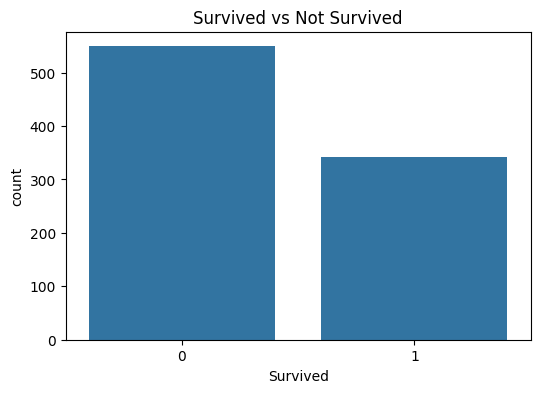

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=titanic)
plt.title('Survived vs Not Survived')
plt.show()

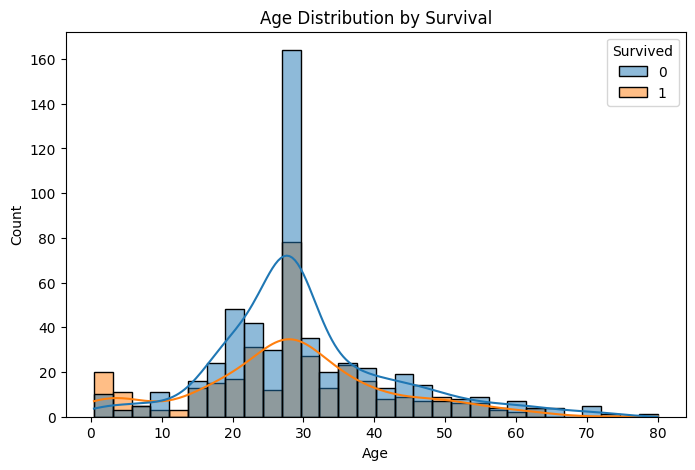

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(data=titanic,
             x='Age',
             hue='Survived',
             bins=30,
             kde=True)
plt.title('Age Distribution by Survival')
plt.show()

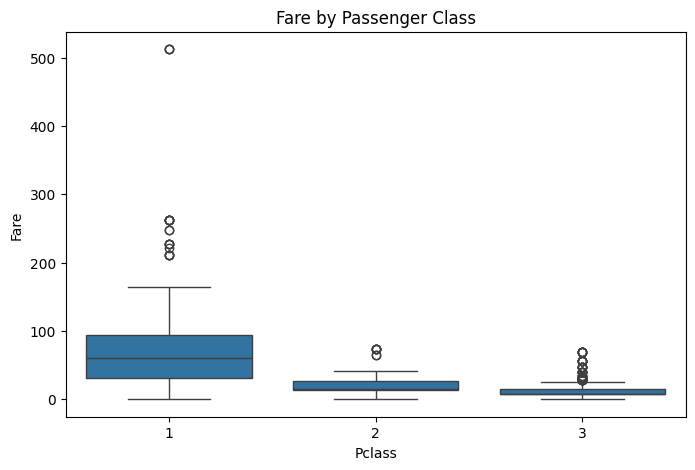

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Fare', data=titanic)
plt.title('Fare by Passenger Class')
plt.show()

SECTION 5: THINK ABOUT IT


In [39]:
#14.
# Passengers most likely to survive:
# Females had a much higher survial rate than males.
# 1st class passengers survived more than 2nd and 3rd class passengers.

In [40]:
#15.
# 1st class passengers may have survived more because:
# Their cabins were closer to lifeboats.
# They received priority during evacuation.
# They had better access to safety information and crew assistance.

BONUS SECTION:


In [ ]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic['Alone'] = titanic['FamilySize'] == 1


In [ ]:
family_survival = titanic.groupby('Alone')['Survived'].mean()
family_survival

Alone
False    0.505650
True     0.303538
Name: Survived, dtype: float64

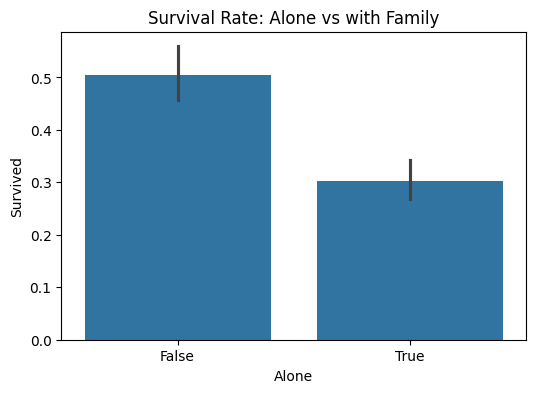

In [48]:
plt.figure(figsize=(6,4))
sns.barplot(x='Alone', y='Survived', data=titanic)
plt.title('Survival Rate: Alone vs with Family')
plt.show()

In [49]:
# yes passengers with family survied more than those travelling alone.